# PCA Exercise (Online Dataset) — Template

Dataset: **UCI Wine Quality (red)** (downloaded directly from an online URL).

Goal: Practice a full PCA workflow (centering → covariance → eigenpairs → projection → explained variance → visualization → reconstruction).


## 0. Imports
Run this cell first.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


## 1. Load an online dataset
We use the UCI Wine Quality (red) dataset.

**Task:** load the CSV from the URL, inspect the columns, and separate features `X` and label `y`.

- Features: all columns except `quality`
- Label: `quality` (integer score)


In [18]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
# TODO: Load the dataset into a pandas DataFrame called df.
# Hint: the separator is ';'

df = pd.DataFrame(pd.read_csv(url, sep= ";"))

# TODO: Print df.shape and df.head()
print(df.shape)
print(df.head())

# TODO: Create X (numpy array of features) and y (numpy array of quality)
X = df.drop('quality', axis=1)
y = df['quality']

# TODO: Print X.shape, y.shape


(1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.

## 2. Implement PCA from scratch
We work with the covariance matrix of **centered** data.

**Math:** If \(X\in\mathbb{R}^{n\times m}\) (rows are samples), let
$$\mu = \frac{1}{n}\sum_{i=1}^n x_i,\quad Y=X-\mathbf{1}\mu^T,\quad S=\frac{1}{n-1}Y^T Y.$$
Then PCA uses eigenpairs \(S u_k=\lambda_k u_k\) with \(\lambda_1\ge\cdots\ge\lambda_m\ge 0\).


In [22]:
# TODO: Implement helper functions.
# 1) center(X) -> (Y, mu)
# 2) covariance_matrix(Y) -> S
# 3) pca_from_cov(S) -> (evals_desc, evecs_desc)

def center(X):
    mu = X.mean(axis=0)
    Y = X - mu
    return Y, mu

def covariance_matrix(Y):
    n = Y.shape[0]
    return (Y.T @ Y) / (n - 1)

def pca_from_cov(S):
    evals, evecs = np.linalg.eigh(S)
    idx = np.argsort(evals)[::-1]
    return evals[idx], evecs[:, idx]


## 3. Run PCA and compute explained variance
**Task:**
1. Center X → Y
2. Covariance S
3. Eigendecompose S → eigenvalues/eigenvectors
4. Compute explained variance ratio (EVR)
5. Find smallest k such that cumulative EVR ≥ 0.95


In [33]:
# TODO: Run PCA
Y, mu = center(X)
S = covariance_matrix(Y)
evals, U = pca_from_cov(S)

# TODO: EVR
total = np.sum(evals)
evr = evals / total
cum = np.cumsum(evr)

# TODO: find k95 (smallest k with cum[k-1] >= 0.95)
k95 = np.argmax(cum >= 0.95) +1

# Print: first 10 eigenvalues, first 10 EVR, and k95
print("first 10 eigenvalues:", evals[:10])
print("first 10 EVR:", evr[:10])
print("k95:", k95)


first 10 eigenvalues: [1133.807076   57.935411    3.101302    1.819415    1.04634     0.041397
    0.023193    0.011346    0.010078    0.001455]
first 10 EVR: [0.946577 0.048368 0.002589 0.001519 0.000874 0.000035 0.000019 0.000009
 0.000008 0.000001]
k95: 2


## 4. Visualize EVR and cumulative EVR
**Task:** make two plots:
- bar plot of EVR for the first 10 PCs
- line plot of cumulative EVR for all PCs, with a horizontal line at 0.95


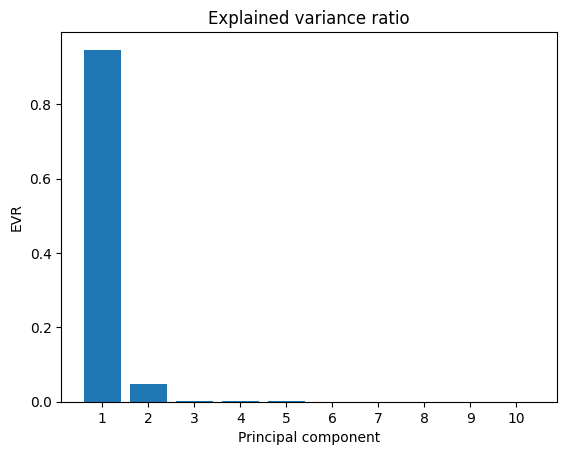

In [37]:
# TODO: Make EVR bar plot (first 10)
# TODO: Make cumulative EVR line plot (all)
plt.figure()
plt.bar(range(1, 11), evr[:10])
plt.title("Explained variance ratio")
plt.xlabel("Principal component")
plt.ylabel("EVR")
plt.xticks(range(1,11))
plt.show()

## 5. Project data to 2D (PC1–PC2) and color by quality
**Task:**
- Compute PC scores $Z = Y U_k$
- For a 2D scatter, use $Z_2 = Y [u_1, u_2]$
- Color points by wine quality.


In [ ]:
# TODO: Compute Z2 (n x 2)
# Z2 = ...

# TODO: Make a scatter plot of Z2[:,0] vs Z2[:,1] colored by y
# Use plt.scatter(..., c=y)


## 6. Reconstruction and error vs k
**Task:** for each $k=1,2,\dots,K$ (take $K=10$ or $K=k95$, whichever is smaller):
- $Z_k = YU_k$
- $\hat{X}_k = \mu + Z_k U_k^T$
- MSE = mean squared error over all entries

Plot MSE vs k.


In [ ]:
# TODO: Choose K = min(10, k95)
# TODO: Loop over k=1..K computing reconstruction and MSE
# TODO: Plot MSE vs k


## 7. Short questions (answer in Markdown)
1. Why do we **center** the data before PCA?
2. What does an eigenvector entry (loading) mean?
3. What does it mean if PC2 has opposite signs for two features?


**Your answers:**

1.
2.
3.
